# Pronóstico semanal de concentración de NOx en Angamos 1

**Trabajo final - Series de Tiempo**  
**Equipo:** Hans Walter Engelmann Cabrera, Jessica Anaid Aguilar Mejía, Matías Nicolás García Garcete y Guillermo Eder López Rojas

## 1. Problema y objetivo

La fuente es el sistema SNIFA de la Superintendencia del Medio Ambiente. Se estudian registros horarios reportados para la central `ANGAMOS`, unidad `ANGAMOS 1`, y la variable continua `CONCENTRACION_NOX_MG_NM3`.

**Objetivo general:** modelar y pronosticar la concentración semanal media reportada y medida (`DM`) de NOx de Angamos 1, considerando todos los estados operacionales, comparando modelos de series de tiempo con criterios explícitos y generando un pronóstico de ocho semanas con intervalos predictivos del 95%.

La magnitud analizada es una **concentración en mg/Nm³**; no corresponde a masa total emitida ni debe expresarse en toneladas.

## 2. Diseño previo del análisis

La unidad temporal es la semana terminada en domingo. Antes de cualquier diagnóstico o propuesta de modelos se reserva cronológicamente una validación de 32 semanas y una prueba final de 8 semanas. ADF, ACF y PACF se calculan exclusivamente con las 259 semanas de entrenamiento. Las imputaciones se realizan por separado dentro de cada etapa, sin usar observaciones de una partición posterior. La selección exige residuos compatibles con ruido blanco y luego minimiza el RMSE de validación calculado sólo sobre semanas realmente observadas. La prueba permanece fuera de la selección.


In [1]:
from pathlib import Path
import json
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import statsmodels
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing, Holt, SimpleExpSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")
np.random.seed(20260719)

ROOT = Path.cwd().resolve()
ENTREGA = ROOT if (ROOT / "data").exists() else ROOT / "Guillermo_repo_review" / "entrega"
DATA = ENTREGA / "data"
TABLES = ENTREGA / "resultados" / "tablas"
FIGURES = ENTREGA / "resultados" / "figuras"
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

H_VALIDACION = 32
H_PRUEBA = 8
H_PRONOSTICO = 8
PERIODO_ESTACIONAL = 52
UMBRAL_COBERTURA = 0.75

print(f"Directorio de entrega: {ENTREGA}")
print(f"Resultados: {TABLES.parent}")
versiones = pd.DataFrame({"componente": ["Python", "numpy", "pandas", "matplotlib", "scikit-learn", "statsmodels"],
                         "version": [sys.version.split()[0], np.__version__, pd.__version__, matplotlib.__version__, sklearn.__version__, statsmodels.__version__]})
versiones.to_csv(TABLES / "14_versiones_software.csv", index=False)
display(versiones)


Directorio de entrega: C:\Users\bassi\Desktop\PUC\2026\b2\st\Módulo 4 - Procesos no Estacionarios y Estacionales - Semana 8\Trabajo Final\Guillermo_repo_review\entrega
Resultados: C:\Users\bassi\Desktop\PUC\2026\b2\st\Módulo 4 - Procesos no Estacionarios y Estacionales - Semana 8\Trabajo Final\Guillermo_repo_review\entrega\resultados


,componente,version
0,Python,3.13.6
1,numpy,2.3.2
2,pandas,2.3.1
3,matplotlib,3.10.6
4,scikit-learn,1.7.1
5,statsmodels,0.14.5


## 3. Auditoría y construcción de la base

Se importa `data/angamos1_nox_horaria_filtrada.csv`, que es la base abierta entregada como anexo y conserva los 50.400 registros de Angamos 1 obtenidos desde los 23 CSV trimestrales de SNIFA. El extracto incluye fecha, concentración, códigos de calidad y estado operacional, además del archivo de origen, por lo que mantiene la trazabilidad sin exigir al evaluador descargar cerca de 3 GB.

A partir de esta base, el notebook reproduce la auditoría, la agregación semanal y todo el modelamiento.

In [2]:
horaria = pd.read_csv(
    DATA / "angamos1_nox_horaria_filtrada.csv",
    parse_dates=["fecha"]
)

assert horaria["fecha"].notna().all()
assert not horaria["fecha"].duplicated().any()
assert horaria["fecha"].is_monotonic_increasing

print(f"Registros horarios: {len(horaria):,}")
print(f"Periodo: {horaria['fecha'].min()} a {horaria['fecha'].max()}")
display(horaria.head())

Registros horarios: 50,400
Periodo: 2020-01-01 00:00:00 a 2025-09-30 23:00:00


,fecha,nox_mg_nm3,potencia_bruta_mwh,tipo_dato_nox,estado_uge,chimenea,es_medicion,es_regimen_re,valor_objetivo_valido,archivo_origen,periodo_archivo
0,2020-01-01 00:00:00,337.062988,551.038025,DM,RE,ANGAMOS,True,True,True,PH2020-1_Act2024-03-11.csv,2020-1
1,2020-01-01 01:00:00,348.394989,553.361023,DM,RE,ANGAMOS,True,True,True,PH2020-1_Act2024-03-11.csv,2020-1
2,2020-01-01 02:00:00,352.332001,553.200989,DM,RE,ANGAMOS,True,True,True,PH2020-1_Act2024-03-11.csv,2020-1
3,2020-01-01 03:00:00,347.329987,558.588989,DM,RE,ANGAMOS,True,True,True,PH2020-1_Act2024-03-11.csv,2020-1
4,2020-01-01 04:00:00,344.106995,553.310974,DM,RE,ANGAMOS,True,True,True,PH2020-1_Act2024-03-11.csv,2020-1


In [3]:
resumen_auditoria = pd.Series({
    "archivos originales": horaria["archivo_origen"].nunique(),
    "registros Angamos 1": len(horaria),
    "fechas inválidas": horaria["fecha"].isna().sum(),
    "duplicados fecha-hora": horaria["fecha"].duplicated().sum(),
    "mediciones DM válidas": horaria["valor_objetivo_valido"].sum(),
}, name="resultado")

cobertura_anual = (
    horaria.assign(anio=horaria["fecha"].dt.year)
    .groupby("anio")
    .agg(registros=("fecha", "size"),
         horas_unicas=("fecha", "nunique"),
         mediciones_validas=("valor_objetivo_valido", "sum"))
)
tipo_dato = horaria["tipo_dato_nox"].value_counts().rename_axis("tipo").to_frame("n")
tipo_dato["porcentaje"] = 100 * tipo_dato["n"] / len(horaria)
estado_uge = horaria["estado_uge"].value_counts().rename_axis("estado").to_frame("n")
estado_uge["porcentaje"] = 100 * estado_uge["n"] / len(horaria)

cobertura_anual.to_csv(TABLES / "01_cobertura_anual.csv")
pd.DataFrame({"chimenea": sorted(horaria["chimenea"].dropna().unique())}).to_csv(
    TABLES / "02_chimeneas.csv", index=False
)
tipo_dato.to_csv(TABLES / "03_tipo_dato_nox.csv")
estado_uge.to_csv(TABLES / "04_estado_uge.csv")
horaria.loc[horaria["fecha"].duplicated(keep=False)].to_csv(
    TABLES / "05_duplicados_fecha_hora.csv", index=False
)
(TABLES / "resumen_auditoria.json").write_text(
    json.dumps({k: int(v) for k, v in resumen_auditoria.items()}, ensure_ascii=False, indent=2),
    encoding="utf-8"
)
display(resumen_auditoria, cobertura_anual, tipo_dato, estado_uge)


archivos originales         23
registros Angamos 1      50400
fechas inválidas             0
duplicados fecha-hora        0
mediciones DM válidas    48574
Name: resultado, dtype: int64

,registros,horas_unicas,mediciones_validas
anio,,,
2020,8784,8784,8514
2021,8760,8760,8284
2022,8760,8760,8396
2023,8760,8760,8398
2024,8784,8784,8651
2025,6552,6552,6331


,n,porcentaje
tipo,,
DM,48574,96.376984
DS,1826,3.623016


,n,porcentaje
estado,,
RE,47208,93.666667
HE,1310,2.599206
FA,1081,2.144841
DP,394,0.781746
DNP,241,0.478175
HA,166,0.329365


### Resultado de la auditoría

Se encontraron 50.400 observaciones horarias continuas, ninguna fecha inválida y ningún duplicado fecha-hora. El 96,38% de los registros corresponde a códigos de medición (`DM`), mientras que 3,62% corresponde a datos sustituidos (`DS`).

La cobertura permite continuar: 289 de las 301 semanas inicialmente formadas superaron simultáneamente las reglas de cobertura y borde. Para mantener un índice semanal regular se excluyeron las dos semanas parciales de los extremos y se interpolaron diez semanas interiores con cobertura inferior al 75%; los vacíos fueron aislados o de un máximo de dos semanas.

In [4]:
base_valida = horaria.loc[horaria["valor_objetivo_valido"]].copy()
semanal = (
    base_valida.set_index("fecha")["nox_mg_nm3"]
    .resample("W-SUN")
    .agg(["count", "mean", "median", "std", "min", "max"])
    .rename(columns={
        "count": "horas_validas", "mean": "nox_media_mg_nm3",
        "median": "nox_mediana_mg_nm3", "std": "nox_sd_mg_nm3",
        "min": "nox_min_mg_nm3", "max": "nox_max_mg_nm3"
    })
)
semanal["cobertura"] = semanal["horas_validas"] / 168
fecha_min = base_valida["fecha"].min().normalize()
fecha_max = base_valida["fecha"].max().normalize()
semana_completa = (
    (semanal.index - pd.Timedelta(days=6) >= fecha_min)
    & (semanal.index <= fecha_max)
)
semanal = semanal.loc[semana_completa].asfreq("W-SUN")
semanal["valor_observado_mg_nm3"] = semanal["nox_media_mg_nm3"].where(
    semanal["cobertura"] >= UMBRAL_COBERTURA
)
semanal["valor_imputado"] = semanal["valor_observado_mg_nm3"].isna()

assert semanal.index.to_series().diff().dropna().eq(pd.Timedelta(days=7)).all()
assert len(semanal) == 299 and semanal["valor_imputado"].sum() == 10

semanal.to_csv(TABLES / "06_auditoria_semanal.csv")
print("Semanas completas:", len(semanal))
print("Semanas realmente observadas con cobertura >= 75%:", int((~semanal["valor_imputado"]).sum()))
print("Semanas que requieren imputación para ajustar modelos:", int(semanal["valor_imputado"].sum()))
display(semanal.head())


Semanas completas: 299
Semanas realmente observadas con cobertura >= 75%: 289
Semanas que requieren imputación para ajustar modelos: 10


,horas_validas,nox_media_mg_nm3,nox_mediana_mg_nm3,nox_sd_mg_nm3,nox_min_mg_nm3,nox_max_mg_nm3,cobertura,valor_observado_mg_nm3,valor_imputado
fecha,,,,,,,,,
2020-01-12,164,313.305945,306.957001,33.236959,259.351013,419.552002,0.976190,313.305945,False
2020-01-19,161,309.019093,303.806000,28.570807,270.040009,408.355988,0.958333,309.019093,False
2020-01-26,148,356.078129,358.057495,37.991371,294.877991,428.488007,0.880952,356.078129,False
2020-02-02,166,334.356626,330.459000,26.729993,283.459991,406.763000,0.988095,334.356626,False
2020-02-09,167,325.446917,325.773987,58.817038,233.460999,561.830017,0.994048,325.446917,False


## 4. Partición temporal e imputación por etapa

La partición se realiza sobre la serie semanal observada, antes de interpolar y antes de calcular ADF, ACF o PACF. Cada bloque se imputa de manera independiente mediante interpolación temporal interior (máximo dos semanas consecutivas); por tanto, ninguna observación de validación o prueba puede intervenir en la preparación del entrenamiento. Los valores imputados sirven únicamente para mantener la regularidad requerida por los modelos y nunca se usan como valores reales al calcular métricas.


,conjunto,n_semanas,n_observadas,n_imputadas,inicio,fin
0,Entrenamiento,259,250,9,2020-01-12,2024-12-22
1,Validación,32,32,0,2024-12-29,2025-08-03
2,Prueba final,8,7,1,2025-08-10,2025-09-28


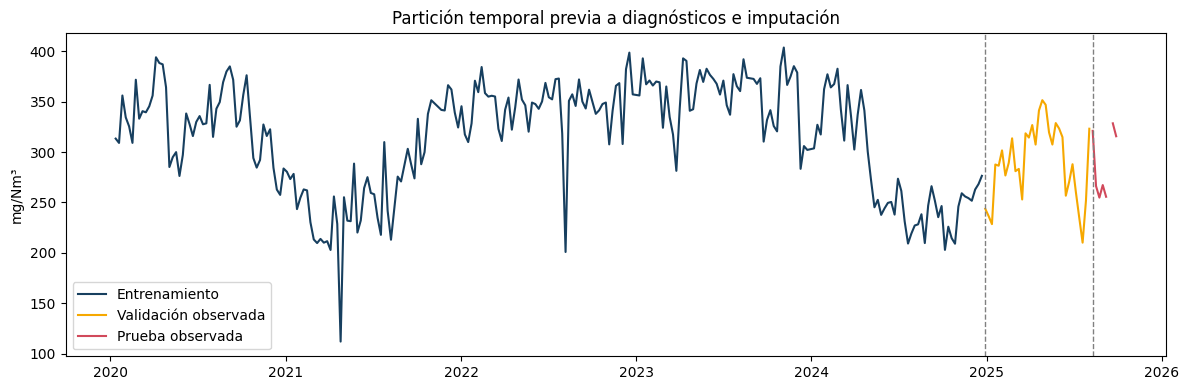

In [5]:
def imputar_etapa(observada, nombre):
    imputada = observada.astype(float).interpolate(
        method="time", limit=2, limit_area="inside"
    )
    if imputada.isna().any():
        faltantes = imputada.index[imputada.isna()].strftime("%Y-%m-%d").tolist()
        raise ValueError(f"{nombre}: quedaron semanas no imputables sin extrapolar: {faltantes}")
    return imputada

serie_observada = semanal["valor_observado_mg_nm3"].astype(float)
train_observado = serie_observada.iloc[:-(H_VALIDACION + H_PRUEBA)]
validacion_observada = serie_observada.iloc[-(H_VALIDACION + H_PRUEBA):-H_PRUEBA]
prueba_observada = serie_observada.iloc[-H_PRUEBA:]

train = imputar_etapa(train_observado, "entrenamiento")
validacion_modelo = imputar_etapa(validacion_observada, "validación")
prueba_modelo = imputar_etapa(prueba_observada, "prueba")
mascara_validacion_observada = validacion_observada.notna().to_numpy()
mascara_prueba_observada = prueba_observada.notna().to_numpy()

particiones = pd.DataFrame({
    "conjunto": ["Entrenamiento", "Validación", "Prueba final"],
    "n_semanas": [len(train), len(validacion_modelo), len(prueba_modelo)],
    "n_observadas": [train_observado.notna().sum(), validacion_observada.notna().sum(), prueba_observada.notna().sum()],
    "n_imputadas": [train_observado.isna().sum(), validacion_observada.isna().sum(), prueba_observada.isna().sum()],
    "inicio": [train.index.min(), validacion_modelo.index.min(), prueba_modelo.index.min()],
    "fin": [train.index.max(), validacion_modelo.index.max(), prueba_modelo.index.max()],
})
particiones.to_csv(TABLES / "06b_particiones_temporales.csv", index=False)
display(particiones)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train, label="Entrenamiento", color="#173f5f")
ax.plot(validacion_observada, label="Validación observada", color="#f6a800")
ax.plot(prueba_observada, label="Prueba observada", color="#d1495b")
ax.axvline(validacion_modelo.index[0], color="gray", linestyle="--", linewidth=1)
ax.axvline(prueba_modelo.index[0], color="gray", linestyle="--", linewidth=1)
ax.set(title="Partición temporal previa a diagnósticos e imputación", ylabel="mg/Nm³")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES / "04_particion_temporal.png", dpi=180, bbox_inches="tight")
plt.show()


### Control de la separación temporal

El entrenamiento contiene 259 semanas (250 observadas y 9 imputadas), la validación 32 semanas observadas y la prueba 8 semanas (7 observadas y 1 imputada). La semana imputada de prueba no interviene en el ajuste que genera su pronóstico ni en las métricas. Sólo se incorpora, dentro de su propio bloque, cuando los datos completos ya están disponibles y se ajusta el modelo final para pronosticar el futuro.


,NOx entrenamiento (mg/Nm³)
count,259.000000
mean,315.763281
std,54.053534
min,111.902796
25%,273.681616
50%,331.380238
75%,358.920333
max,403.672503


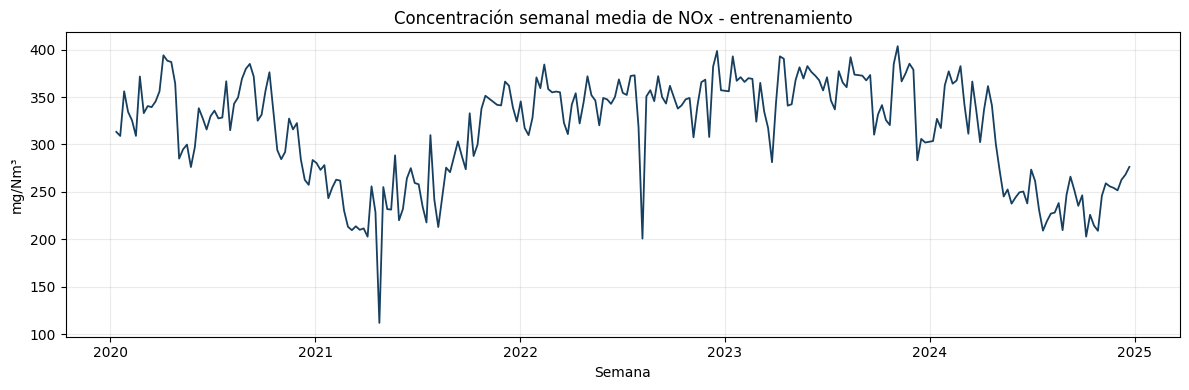

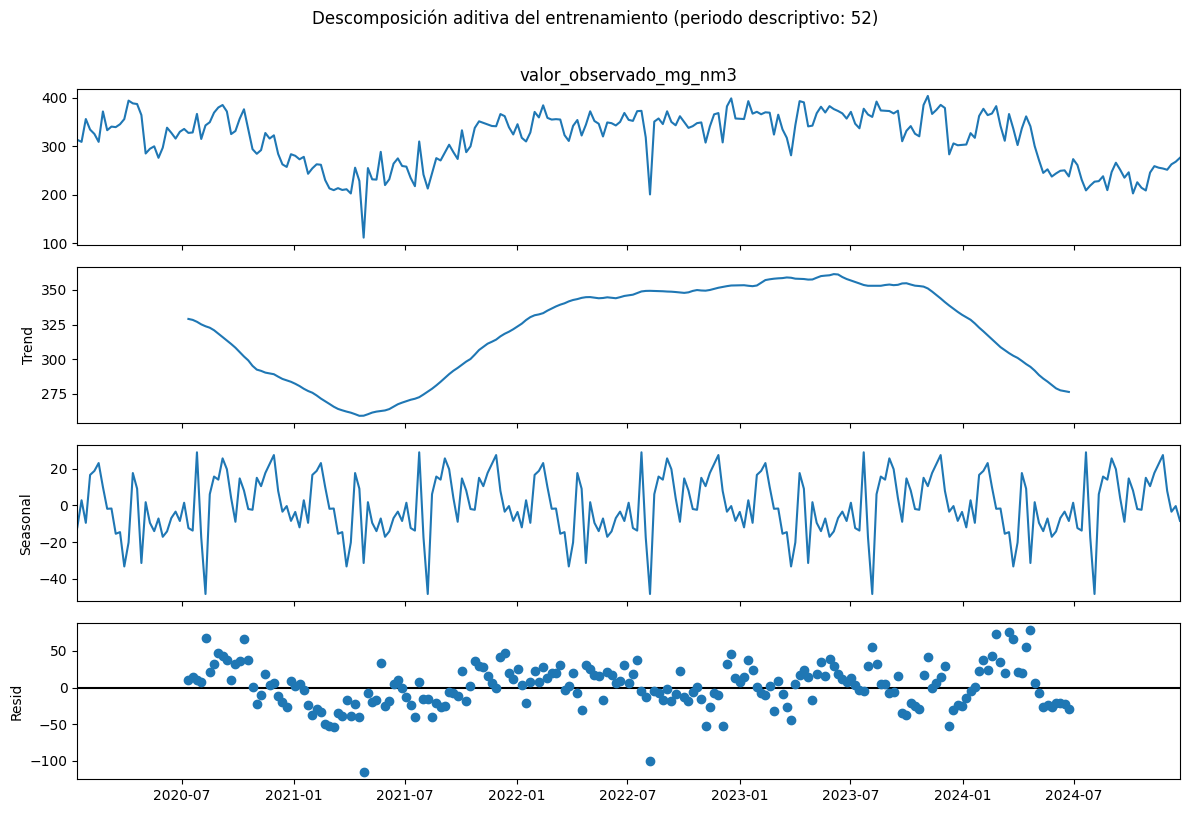

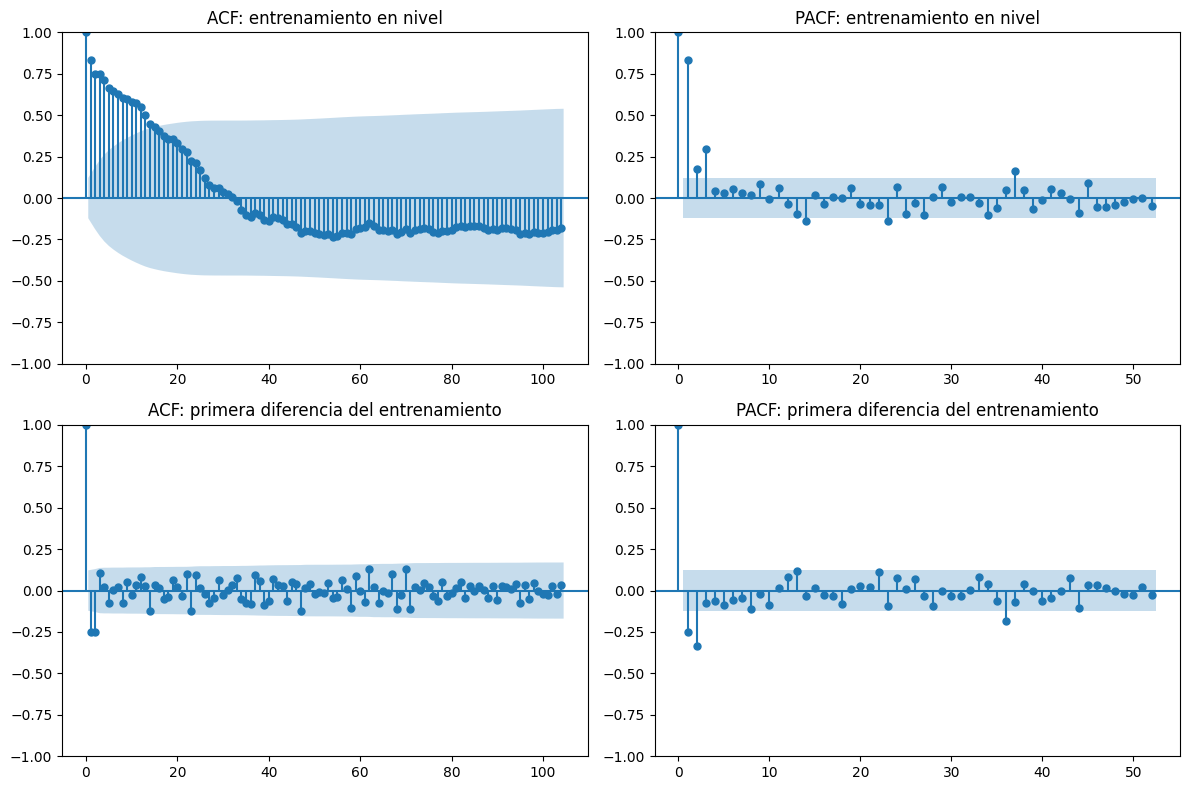

,serie,estadístico ADF,p_value,n_observaciones
0,Entrenamiento en nivel,-2.673441,7.874800e-02,256
1,Primera diferencia del entrenamiento,-17.933385,2.877840e-30,256


In [6]:
# Diagnósticos y propuestas construidos exclusivamente con entrenamiento.
estadisticos_train = train.describe().to_frame("NOx entrenamiento (mg/Nm³)")
estadisticos_train.to_csv(TABLES / "11_estadisticos_descriptivos.csv")
display(estadisticos_train)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train, color="#173f5f", linewidth=1.3)
ax.set(title="Concentración semanal media de NOx - entrenamiento",
       xlabel="Semana", ylabel="mg/Nm³")
ax.grid(alpha=0.25)
plt.tight_layout()
fig.savefig(FIGURES / "01_serie_historica.png", dpi=180, bbox_inches="tight")
plt.show()

descomposicion = seasonal_decompose(train, model="additive", period=52)
fig = descomposicion.plot()
fig.set_size_inches(12, 8)
fig.suptitle("Descomposición aditiva del entrenamiento (periodo descriptivo: 52)", y=1.01)
plt.tight_layout()
fig.savefig(FIGURES / "02_descomposicion.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_acf(train, lags=104, ax=axes[0, 0])
plot_pacf(train, lags=52, ax=axes[0, 1], method="ywm")
dtrain = train.diff().dropna()
plot_acf(dtrain, lags=104, ax=axes[1, 0])
plot_pacf(dtrain, lags=52, ax=axes[1, 1], method="ywm")
axes[0, 0].set_title("ACF: entrenamiento en nivel")
axes[0, 1].set_title("PACF: entrenamiento en nivel")
axes[1, 0].set_title("ACF: primera diferencia del entrenamiento")
axes[1, 1].set_title("PACF: primera diferencia del entrenamiento")
plt.tight_layout()
fig.savefig(FIGURES / "03_acf_pacf.png", dpi=180, bbox_inches="tight")
plt.show()

adf_nivel = adfuller(train)
adf_diferencia = adfuller(dtrain)
tabla_adf = pd.DataFrame({
    "serie": ["Entrenamiento en nivel", "Primera diferencia del entrenamiento"],
    "estadístico ADF": [adf_nivel[0], adf_diferencia[0]],
    "p_value": [adf_nivel[1], adf_diferencia[1]],
    "n_observaciones": [adf_nivel[3], adf_diferencia[3]]
})
tabla_adf.to_csv(TABLES / "13_adf_entrenamiento.csv", index=False)
display(tabla_adf)


En las 259 semanas de entrenamiento, el ADF en nivel entrega un estadístico de -2,673 y un valor p de 0,079, por lo que no se rechaza la raíz unitaria al 5%. En primera diferencia el valor p es prácticamente cero. ACF y PACF, examinadas sólo en entrenamiento, sustentan candidatos parsimoniosos con (d=0) y (d=1); el periodo 52 se conserva como comparación descriptiva/estacional. Ningún dato de validación o prueba participa en esta propuesta.


## 5. Modelos y criterio de selección


In [7]:
ordenes_arima = [(1, 0, 0), (3, 0, 0), (1, 1, 0), (2, 1, 0), (0, 1, 1), (0, 1, 2)]
print("Candidatos ARIMA propuestos sólo con entrenamiento:", ordenes_arima)


Candidatos ARIMA propuestos sólo con entrenamiento: [(1, 0, 0), (3, 0, 0), (1, 1, 0), (2, 1, 0), (0, 1, 1), (0, 1, 2)]


In [8]:
# La figura de partición ya fue generada antes de ADF/ACF/PACF.
display(particiones)


,conjunto,n_semanas,n_observadas,n_imputadas,inicio,fin
0,Entrenamiento,259,250,9,2020-01-12,2024-12-22
1,Validación,32,32,0,2024-12-29,2025-08-03
2,Prueba final,8,7,1,2025-08-10,2025-09-28


## 6. Comparación y selección en validación

Se comparan tres baselines, SES, Holt amortiguado, ETS aditivo de periodo 52 y seis ARIMA propuestos con el entrenamiento. Las métricas se calculan sólo donde el bloque de validación contiene una semana realmente observada. Para los ARIMA, Ljung–Box elimina primero los residuos iniciales definidos por `loglikelihood_burn` y usa `model_df = p + q`. La regla de selección no fija de antemano un ganador: entre los modelos con (p>0{,}05) se elige el menor RMSE observado de validación.


In [9]:
def calcular_metricas(real, pred):
    real, pred = np.asarray(real, dtype=float), np.asarray(pred, dtype=float)
    return {
        "RMSE": float(np.sqrt(mean_squared_error(real, pred))),
        "MAE": float(mean_absolute_error(real, pred)),
        "MAPE": float(np.mean(np.abs((real - pred) / real)) * 100),
        "sMAPE": float(100 * np.mean(2 * np.abs(real - pred) / (np.abs(real) + np.abs(pred)))),
    }

def pronostico_ingenuo(y, h):
    return np.repeat(float(y.iloc[-1]), h)

def pronostico_estacional(y, h, periodo=52):
    patron = y.iloc[-periodo:].to_numpy()
    return np.array([patron[i % periodo] for i in range(h)])

def pronostico_drift(y, h):
    pendiente = (y.iloc[-1] - y.iloc[0]) / (len(y) - 1)
    return y.iloc[-1] + pendiente * np.arange(1, h + 1)

def ajustar_modelo(nombre, y, h):
    if nombre == "Ingenuo último valor":
        return {"modelo": nombre, "ajuste": None, "pronostico": pronostico_ingenuo(y, h), "AIC": np.nan}
    if nombre == "Ingenuo estacional 52":
        return {"modelo": nombre, "ajuste": None, "pronostico": pronostico_estacional(y, h), "AIC": np.nan}
    if nombre == "Drift":
        return {"modelo": nombre, "ajuste": None, "pronostico": pronostico_drift(y, h), "AIC": np.nan}
    if nombre == "SES":
        ajuste = SimpleExpSmoothing(y, initialization_method="estimated").fit()
    elif nombre == "Holt amortiguado":
        ajuste = Holt(y, damped_trend=True, initialization_method="estimated").fit()
    elif nombre == "ETS aditivo 52":
        ajuste = ExponentialSmoothing(
            y, trend="add", damped_trend=True, seasonal="add",
            seasonal_periods=52, initialization_method="estimated"
        ).fit(optimized=True, use_brute=False)
    elif nombre.startswith("ARIMA"):
        orden = tuple(int(x) for x in nombre.removeprefix("ARIMA(").removesuffix(")").split(","))
        tendencia = "c" if orden[1] == 0 else None
        ajuste = SARIMAX(
            y, order=orden, trend=tendencia,
            enforce_stationarity=False, enforce_invertibility=False
        ).fit(disp=False, maxiter=200, cov_type="none")
    else:
        raise ValueError(f"Modelo desconocido: {nombre}")
    pred = (np.asarray(ajuste.get_forecast(h).predicted_mean)
            if hasattr(ajuste, "get_forecast") else np.asarray(ajuste.forecast(h)))
    return {"modelo": nombre, "ajuste": ajuste, "pronostico": pred, "AIC": float(ajuste.aic)}

def residuos_y_df(resultado, y):
    nombre, ajuste = resultado["modelo"], resultado["ajuste"]
    burn, model_df = 0, 0
    if nombre.startswith("ARIMA"):
        orden = tuple(int(x) for x in nombre.removeprefix("ARIMA(").removesuffix(")").split(","))
        model_df = orden[0] + orden[2]
        burn = int(getattr(ajuste, "loglikelihood_burn", getattr(ajuste.model, "loglikelihood_burn", 0)))
        residuos = np.asarray(ajuste.resid).squeeze()[burn:]
    elif ajuste is not None:
        residuos = np.asarray(ajuste.resid).squeeze()
    elif nombre == "Ingenuo estacional 52":
        residuos = (y - y.shift(52)).dropna().to_numpy()
    elif nombre == "Drift":
        pendiente = (y.iloc[-1] - y.iloc[0]) / (len(y) - 1)
        residuos = (y.diff() - pendiente).dropna().to_numpy()
    else:
        residuos = y.diff().dropna().to_numpy()
    residuos = pd.Series(residuos).replace([np.inf, -np.inf], np.nan).dropna()
    return residuos, burn, model_df

nombres_modelos = [
    "Ingenuo último valor", "Ingenuo estacional 52", "Drift",
    "SES", "Holt amortiguado", "ETS aditivo 52",
    *[f"ARIMA({p},{d},{q})" for p, d, q in ordenes_arima]
]
resultados_validacion = [ajustar_modelo(nombre, train, H_VALIDACION) for nombre in nombres_modelos]
filas, pronosticos_validacion = [], {}
for resultado in resultados_validacion:
    nombre = resultado["modelo"]
    pred = np.asarray(resultado["pronostico"])
    residuos, burn, model_df = residuos_y_df(resultado, train)
    lb = acorr_ljungbox(residuos, lags=[10], model_df=model_df, return_df=True)
    filas.append({
        "modelo": nombre,
        **calcular_metricas(validacion_observada.iloc[mascara_validacion_observada], pred[mascara_validacion_observada]),
        "semanas_validacion_observadas": int(mascara_validacion_observada.sum()),
        "AIC": resultado["AIC"],
        "loglikelihood_burn": burn,
        "model_df": model_df,
        "Ljung_Box_p_10": float(lb["lb_pvalue"].iloc[0])
    })
    pronosticos_validacion[nombre] = pred

comparacion = pd.DataFrame(filas).sort_values(["RMSE", "MAE"]).reset_index(drop=True)
comparacion["ranking_RMSE"] = np.arange(1, len(comparacion) + 1)
apropiados = comparacion.loc[comparacion["Ljung_Box_p_10"] > 0.05]
if apropiados.empty:
    raise RuntimeError("Ningún candidato supera Ljung-Box al 5%.")
modelo_seleccionado = apropiados.sort_values(["RMSE", "MAE"]).iloc[0]["modelo"]
comparacion.to_csv(TABLES / "07_comparacion_validacion.csv", index=False)
print("Modelo seleccionado sin aserción forzada:", modelo_seleccionado)
display(comparacion.style.format({
    "RMSE": "{:.2f}", "MAE": "{:.2f}", "MAPE": "{:.2f}", "sMAPE": "{:.2f}",
    "AIC": "{:.2f}", "Ljung_Box_p_10": "{:.4f}"
}))


Modelo seleccionado sin aserción forzada: ARIMA(3,0,0)


,modelo,RMSE,MAE,MAPE,sMAPE,semanas_validacion_observadas,AIC,loglikelihood_burn,model_df,Ljung_Box_p_10,ranking_RMSE
0,"ARIMA(3,0,0)",35.99,29.24,10.80,10.23,32,2444.29,3,3,0.8225,1
1,Ingenuo último valor,38.93,33.40,11.51,11.71,32,nan,0,0,0.0000,2
2,"ARIMA(1,0,0)",39.10,29.49,11.35,10.33,32,2492.59,1,1,0.0011,3
3,"ARIMA(1,1,0)",39.52,34.01,11.66,11.93,32,2487.54,2,1,0.0001,4
4,Drift,39.91,34.09,11.65,11.96,32,nan,0,0,0.0000,5
5,"ARIMA(2,1,0)",40.63,35.00,11.90,12.29,32,2447.51,3,2,0.4411,6
6,"ARIMA(0,1,1)",41.89,36.11,12.19,12.70,32,2455.43,3,1,0.0537,7
7,SES,41.93,36.15,12.20,12.71,32,1748.37,0,0,0.0768,8
8,Holt amortiguado,42.35,36.46,12.28,12.83,32,1754.36,0,0,0.0779,9
9,"ARIMA(0,1,2)",45.28,38.92,12.97,13.75,32,2435.02,4,2,0.6573,10


**ARIMA(3,0,0)** vuelve a ser el modelo seleccionado, sin haber forzado ese resultado: obtuvo el menor RMSE de validación (35,99 mg/Nm³) y, tras excluir `loglikelihood_burn = 3` y usar `model_df = 3`, su Ljung–Box fue (p=0{,}822). La fila correcta de **ETS aditivo 52** en esta misma ejecución es RMSE 50,18, MAE 38,96 y (p=0{,}224). El ingenuo de último valor quedó segundo por RMSE, pero conservó autocorrelación ((p<0{,}001)).


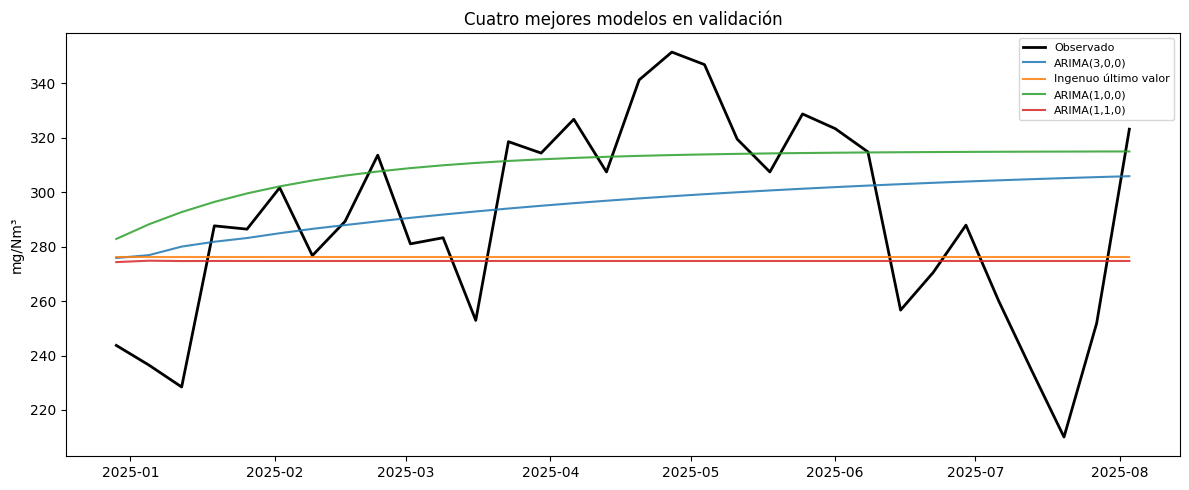

,modelo,semanas_bloque_prueba,semanas_observadas_evaluadas,RMSE,MAE,MAPE,sMAPE
0,"ARIMA(3,0,0)",8,7,30.233987,28.890217,10.315222,10.025562


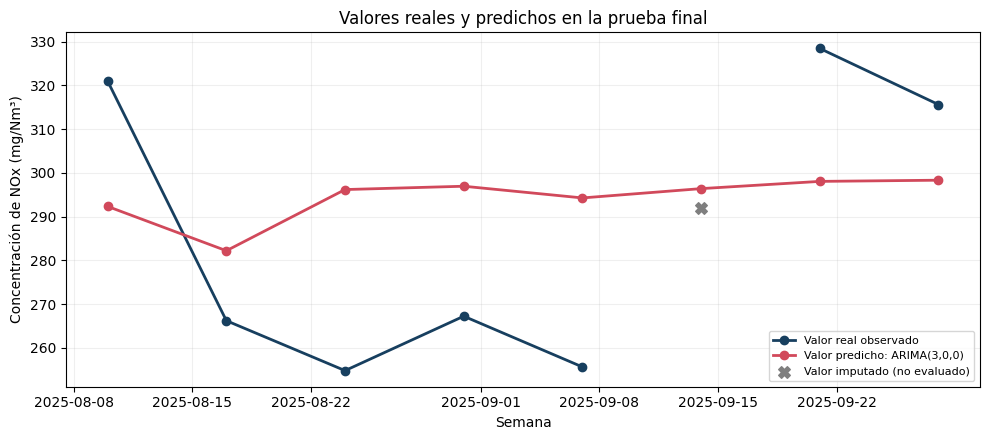

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(validacion_observada, label="Observado", color="black", linewidth=2)
for nombre in comparacion.head(4)["modelo"]:
    ax.plot(validacion_modelo.index, pronosticos_validacion[nombre], label=nombre, alpha=0.85)
ax.set(title="Cuatro mejores modelos en validación", ylabel="mg/Nm³")
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(FIGURES / "05_validacion_modelos.png", dpi=180, bbox_inches="tight")
plt.show()

train_validacion = pd.concat([train, validacion_modelo])
resultado_prueba = ajustar_modelo(modelo_seleccionado, train_validacion, H_PRUEBA)
pred_prueba = np.asarray(resultado_prueba["pronostico"])
metricas_prueba = pd.DataFrame([{
    "modelo": modelo_seleccionado,
    "semanas_bloque_prueba": H_PRUEBA,
    "semanas_observadas_evaluadas": int(mascara_prueba_observada.sum()),
    **calcular_metricas(
        prueba_observada.iloc[mascara_prueba_observada], pred_prueba[mascara_prueba_observada]
    )
}])
metricas_prueba.to_csv(TABLES / "08_metricas_prueba_final.csv", index=False)
display(metricas_prueba)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(prueba_observada, label="Valor real observado", color="#173f5f", marker="o", linewidth=2)
ax.plot(prueba_modelo.index, pred_prueba, label=f"Valor predicho: {modelo_seleccionado}",
        color="#d1495b", marker="o", linewidth=2)
ax.scatter(prueba_modelo.index[~mascara_prueba_observada], prueba_modelo.iloc[~mascara_prueba_observada],
           label="Valor imputado (no evaluado)", color="#7f7f7f", marker="X", s=70, zorder=4)
ax.set(title="Valores reales y predichos en la prueba final", xlabel="Semana",
       ylabel="Concentración de NOx (mg/Nm³)")
ax.grid(alpha=0.2)
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(FIGURES / "06_prueba_final.png", dpi=180, bbox_inches="tight")
plt.show()


## 7. Evaluación final y diagnóstico

ARIMA(3,0,0) se reentrena con entrenamiento más validación, sin utilizar la prueba. Sobre las 7 semanas realmente observadas de las 8 reservadas, obtiene RMSE 30,23, MAE 28,89, MAPE 10,32% y sMAPE 10,03%. Después de esa evaluación, y sólo para producir el pronóstico futuro, se ajusta con las tres etapas disponibles, cada una imputada de forma independiente. En el ajuste final, Ljung–Box corregido entrega (p(10)=0{,}428) y (p(20)=0{,}403), con `burn = 3` y `model_df = 3`.


,lag,lb_stat,lb_pvalue,loglikelihood_burn_excluido,model_df
0,10,7.003740,0.428491,3,3
1,20,17.781746,0.402733,3,3


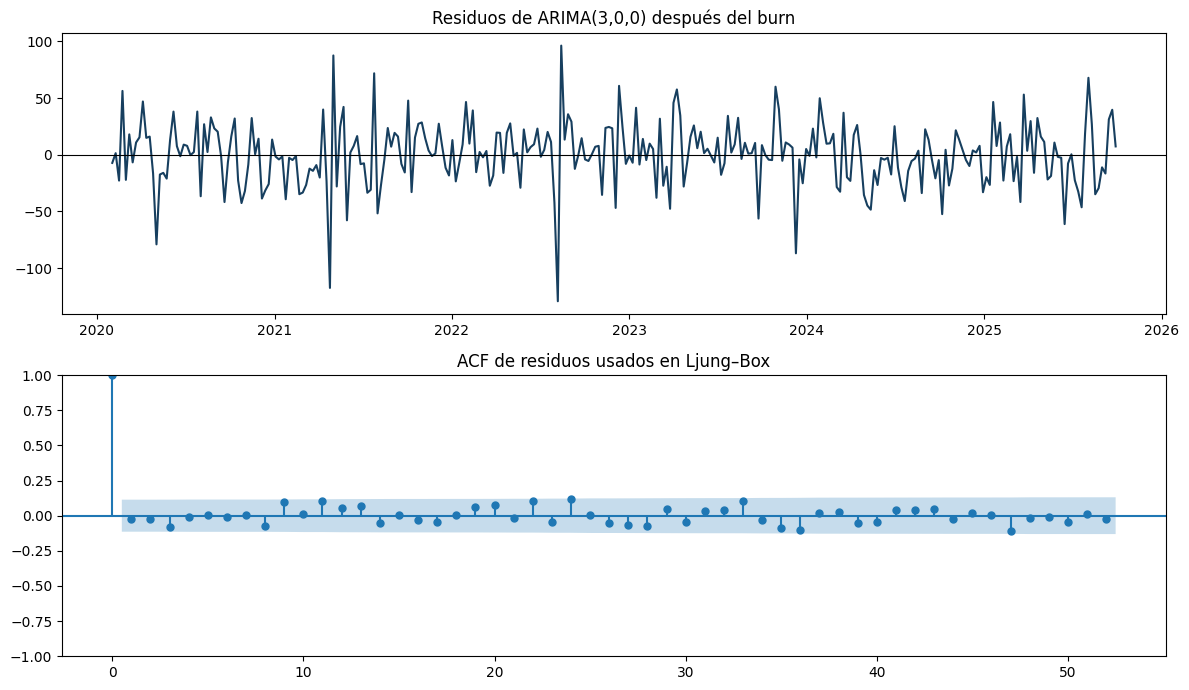

In [11]:
serie_final = pd.concat([train, validacion_modelo, prueba_modelo])
resultado_final = ajustar_modelo(modelo_seleccionado, serie_final, H_PRONOSTICO)
ajuste_final = resultado_final["ajuste"]
residuos_finales, burn_final, model_df_final = residuos_y_df(resultado_final, serie_final)
ljung = acorr_ljungbox(
    residuos_finales, lags=[10, 20], model_df=model_df_final, return_df=True
).reset_index().rename(columns={"index": "lag"})
ljung["loglikelihood_burn_excluido"] = burn_final
ljung["model_df"] = model_df_final
ljung.to_csv(TABLES / "10_ljung_box_modelo_final.csv", index=False)
display(ljung)

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
axes[0].plot(serie_final.index[-len(residuos_finales):], residuos_finales.to_numpy(), color="#173f5f")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title(f"Residuos de {modelo_seleccionado} después del burn")
plot_acf(residuos_finales, lags=52, ax=axes[1])
axes[1].set_title("ACF de residuos usados en Ljung–Box")
plt.tight_layout()
fig.savefig(FIGURES / "08_diagnostico_residuos.png", dpi=180, bbox_inches="tight")
plt.show()


## 8. Pronóstico de ocho semanas


,semana_fin,pronostico_nox_mg_nm3,limite_inferior_95,limite_superior_95,modelo,metodo_intervalo
0,2025-10-05,308.182602,252.895769,363.469435,"ARIMA(3,0,0)","Intervalo predictivo del modelo, 95%"
1,2025-10-12,313.684932,247.376201,379.993664,"ARIMA(3,0,0)","Intervalo predictivo del modelo, 95%"
2,2025-10-19,314.147332,244.301225,383.993439,"ARIMA(3,0,0)","Intervalo predictivo del modelo, 95%"
3,2025-10-26,312.198537,236.933527,387.463548,"ARIMA(3,0,0)","Intervalo predictivo del modelo, 95%"
4,2025-11-02,312.384716,232.215547,392.553885,"ARIMA(3,0,0)","Intervalo predictivo del modelo, 95%"
5,2025-11-09,312.714596,229.288230,396.140961,"ARIMA(3,0,0)","Intervalo predictivo del modelo, 95%"
6,2025-11-16,312.395527,226.177461,398.613592,"ARIMA(3,0,0)","Intervalo predictivo del modelo, 95%"
7,2025-11-23,312.221169,223.492535,400.949803,"ARIMA(3,0,0)","Intervalo predictivo del modelo, 95%"


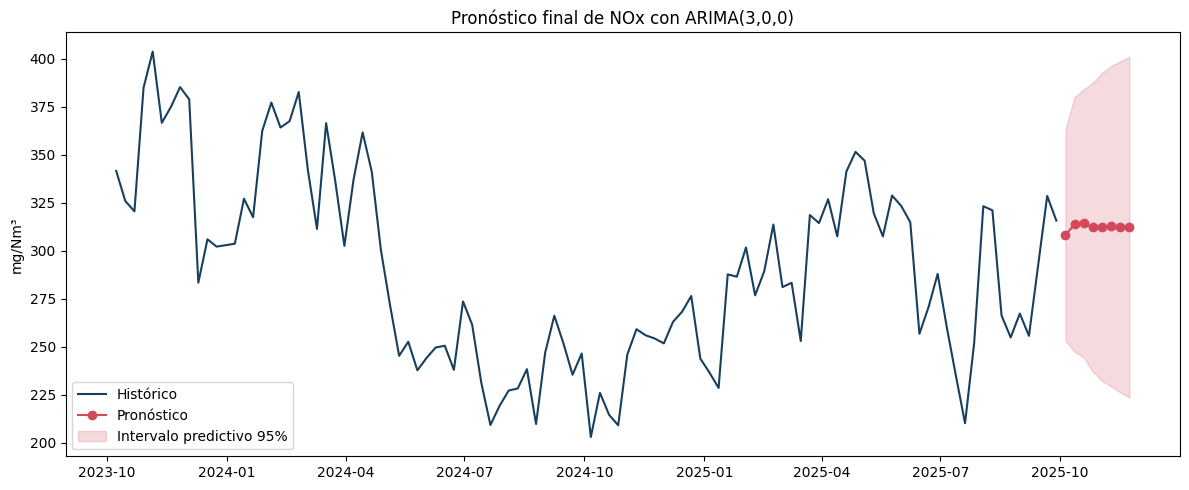

In [12]:
if ajuste_final is None or not hasattr(ajuste_final, "get_forecast"):
    raise RuntimeError("El modelo seleccionado no entrega intervalos predictivos nativos.")
prediccion_final = ajuste_final.get_forecast(H_PRONOSTICO)
pred_central = np.asarray(prediccion_final.predicted_mean)
intervalos = np.asarray(prediccion_final.conf_int(alpha=0.05))
fechas_futuras = pd.date_range(
    serie_final.index[-1] + pd.Timedelta(weeks=1), periods=H_PRONOSTICO, freq="W-SUN"
)
pronostico = pd.DataFrame({
    "semana_fin": fechas_futuras,
    "pronostico_nox_mg_nm3": pred_central,
    "limite_inferior_95": intervalos[:, 0],
    "limite_superior_95": intervalos[:, 1],
    "modelo": modelo_seleccionado,
    "metodo_intervalo": "Intervalo predictivo del modelo, 95%"
})
pronostico.to_csv(TABLES / "09_pronostico_final_8_semanas.csv", index=False)
display(pronostico)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(serie_final.iloc[-104:], label="Histórico", color="#173f5f")
ax.plot(fechas_futuras, pred_central, label="Pronóstico", color="#d1495b", marker="o")
ax.fill_between(fechas_futuras, intervalos[:, 0], intervalos[:, 1],
                color="#d1495b", alpha=0.2, label="Intervalo predictivo 95%")
ax.set(title=f"Pronóstico final de NOx con {modelo_seleccionado}", ylabel="mg/Nm³")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES / "07_pronostico_final.png", dpi=180, bbox_inches="tight")
plt.show()


## 8.1 Análisis de sensibilidad

Se mantuvo el modelo ARIMA(3,0,0) y se modificó la construcción de la serie: umbral 50%, ausencia de umbral, mediana semanal y restricción a mediciones en estado `RE`. Esto permite separar la estabilidad del modelo de las decisiones de limpieza.

,escenario,semanas_imputadas,correlacion_con_base,validacion_RMSE,validacion_MAE,validacion_MAPE,validacion_sMAPE,validacion_semanas_observadas,prueba_RMSE,prueba_MAE,prueba_MAPE,prueba_sMAPE,prueba_semanas_observadas,loglikelihood_burn,model_df,ljung_p_10,ljung_p_20,pronostico_medio_8s,pronostico_min_8s,pronostico_max_8s
0,"Media, cobertura 75%",10,1.000,35.99,29.243177,10.797440,10.233801,32,30.23,28.89,10.315222,10.025562,7,3,3,0.428,0.403,312.24,308.182602,314.147332
1,"Media, cobertura 50%",1,0.950,36.20,28.689426,10.714643,10.046076,32,29.97,28.14,9.923515,9.735626,8,3,3,0.357,0.507,315.36,314.098429,317.938243
2,"Media, sin umbral",0,0.950,36.20,28.690898,10.714689,10.046574,32,29.97,28.14,9.922903,9.735527,8,3,3,0.357,0.506,315.35,314.094642,317.938249
3,"Mediana, cobertura 75%",10,0.975,43.42,35.757644,13.867935,13.000087,32,35.08,31.86,12.603881,12.392232,7,3,3,0.568,0.809,301.67,299.788358,302.717499
4,"Media DM+RE, cobertura 75%",25,0.966,35.96,29.418698,10.763265,10.295012,31,25.78,24.10,8.370770,8.390391,7,3,3,0.019,0.051,305.19,299.234411,306.663800


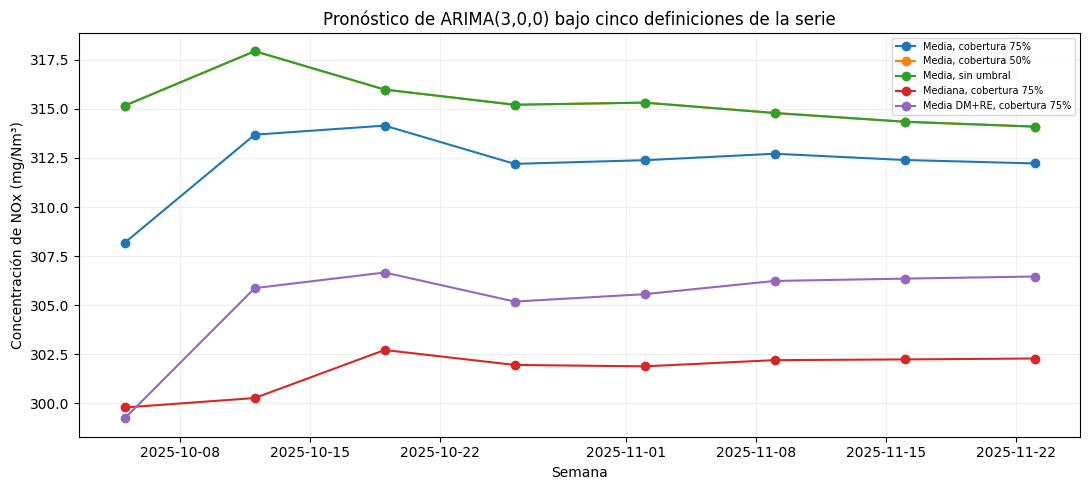

In [13]:
re_semanal = (
    horaria.loc[horaria["valor_objetivo_valido"] & horaria["es_regimen_re"]]
    .set_index("fecha")["nox_mg_nm3"]
    .resample("W-SUN").agg(["count", "mean"])
    .reindex(semanal.index)
)
escenarios_observados = {
    "Media, cobertura 75%": semanal["nox_media_mg_nm3"].where(semanal["cobertura"] >= 0.75),
    "Media, cobertura 50%": semanal["nox_media_mg_nm3"].where(semanal["cobertura"] >= 0.50),
    "Media, sin umbral": semanal["nox_media_mg_nm3"],
    "Mediana, cobertura 75%": semanal["nox_mediana_mg_nm3"].where(semanal["cobertura"] >= 0.75),
    "Media DM+RE, cobertura 75%": re_semanal["mean"].where(re_semanal["count"] / 168 >= 0.75),
}

def preparar_tres_etapas(observada):
    obs_train = observada.iloc[:-(H_VALIDACION + H_PRUEBA)]
    obs_valid = observada.iloc[-(H_VALIDACION + H_PRUEBA):-H_PRUEBA]
    obs_test = observada.iloc[-H_PRUEBA:]
    return (
        obs_train, obs_valid, obs_test,
        imputar_etapa(obs_train, "sensibilidad-entrenamiento"),
        imputar_etapa(obs_valid, "sensibilidad-validación"),
        imputar_etapa(obs_test, "sensibilidad-prueba")
    )

base_partes = preparar_tres_etapas(escenarios_observados["Media, cobertura 75%"])
base_sensibilidad = pd.concat(base_partes[3:6])
filas_sensibilidad, pronosticos_sensibilidad = [], {}
for nombre, observada in escenarios_observados.items():
    obs_train, obs_valid, obs_test, y_train, y_valid, y_test = preparar_tres_etapas(observada)
    mascara_valid = obs_valid.notna().to_numpy()
    mascara_test = obs_test.notna().to_numpy()

    fit_train = ajustar_modelo(modelo_seleccionado, y_train, H_VALIDACION)
    pred_valid = np.asarray(fit_train["pronostico"])
    y_train_valid = pd.concat([y_train, y_valid])
    fit_test = ajustar_modelo(modelo_seleccionado, y_train_valid, H_PRUEBA)
    pred_test = np.asarray(fit_test["pronostico"])
    y_full = pd.concat([y_train, y_valid, y_test])
    fit_full = ajustar_modelo(modelo_seleccionado, y_full, H_PRONOSTICO)
    pred_futuro = np.asarray(fit_full["pronostico"])
    resid, burn, model_df = residuos_y_df(fit_full, y_full)
    lb = acorr_ljungbox(resid, lags=[10, 20], model_df=model_df, return_df=True)
    filas_sensibilidad.append({
        "escenario": nombre,
        "semanas_imputadas": int(observada.isna().sum()),
        "correlacion_con_base": float(y_full.corr(base_sensibilidad)),
        **{f"validacion_{k}": v for k, v in calcular_metricas(
            obs_valid.iloc[mascara_valid], pred_valid[mascara_valid]
        ).items()},
        "validacion_semanas_observadas": int(mascara_valid.sum()),
        **{f"prueba_{k}": v for k, v in calcular_metricas(
            obs_test.iloc[mascara_test], pred_test[mascara_test]
        ).items()},
        "prueba_semanas_observadas": int(mascara_test.sum()),
        "loglikelihood_burn": burn,
        "model_df": model_df,
        "ljung_p_10": float(lb.loc[10, "lb_pvalue"]),
        "ljung_p_20": float(lb.loc[20, "lb_pvalue"]),
        "pronostico_medio_8s": float(pred_futuro.mean()),
        "pronostico_min_8s": float(pred_futuro.min()),
        "pronostico_max_8s": float(pred_futuro.max()),
    })
    pronosticos_sensibilidad[nombre] = pred_futuro

sensibilidad = pd.DataFrame(filas_sensibilidad)
sensibilidad.to_csv(TABLES / "12_analisis_sensibilidad.csv", index=False)
display(sensibilidad.style.format({
    "correlacion_con_base": "{:.3f}", "validacion_RMSE": "{:.2f}",
    "prueba_RMSE": "{:.2f}", "prueba_MAE": "{:.2f}",
    "ljung_p_10": "{:.3f}", "ljung_p_20": "{:.3f}", "pronostico_medio_8s": "{:.2f}"
}))

fig, ax = plt.subplots(figsize=(11, 5))
for nombre, valores in pronosticos_sensibilidad.items():
    ax.plot(fechas_futuras, valores, marker="o", label=nombre)
ax.set(title=f"Pronóstico de {modelo_seleccionado} bajo cinco definiciones de la serie",
       xlabel="Semana", ylabel="Concentración de NOx (mg/Nm³)")
ax.grid(alpha=0.2)
ax.legend(fontsize=7)
plt.tight_layout()
fig.savefig(FIGURES / "10_sensibilidad_pronostico.png", dpi=180, bbox_inches="tight")
plt.show()


La sensibilidad repite la separación por etapas, excluye semanas no observadas de las métricas y corrige Ljung–Box. El escenario principal mantiene (p(10)=0{,}428). Media con cobertura 50%, media sin umbral y mediana también superan el 5%; en cambio, **DM+RE no supera Ljung–Box al rezago 10** ((p=0{,}019), aunque (p(20)=0{,}051)). Su RMSE de validación corregido es 35,96 sobre 31 semanas observadas. Se conserva como especificación principal la media de datos medidos con cobertura mínima de 75%, pues corresponde al objetivo definido antes del modelado; DM+RE representa una pregunta distinta.


## 9. Validación automática de consistencia

Antes de cerrar la ejecución se comprueban explícitamente los registros y semanas, las tres particiones, la tabla completa de modelos, el ganador, las métricas observadas de validación y prueba, Ljung–Box corregido, los cinco escenarios de sensibilidad y los ocho pronósticos con intervalos predictivos válidos.


In [14]:
assert len(horaria) == 50_400
assert len(semanal) == 299 and serie_observada.notna().sum() == 289
assert particiones["n_semanas"].tolist() == [259, 32, 8]
assert particiones["n_observadas"].tolist() == [250, 32, 7]
assert len(comparacion) == 12 and comparacion["modelo"].nunique() == 12
assert modelo_seleccionado == comparacion.loc[
    comparacion["Ljung_Box_p_10"] > 0.05
].sort_values(["RMSE", "MAE"]).iloc[0]["modelo"]
assert (comparacion["semanas_validacion_observadas"] == 32).all()
assert int(metricas_prueba.loc[0, "semanas_observadas_evaluadas"]) == 7
assert set(ljung["lag"]) == {10, 20}
assert (ljung["loglikelihood_burn_excluido"] == burn_final).all()
assert (ljung["model_df"] == model_df_final).all()
assert len(sensibilidad) == 5
assert len(pronostico) == 8
assert (pronostico["limite_inferior_95"] < pronostico["pronostico_nox_mg_nm3"]).all()
assert (pronostico["pronostico_nox_mg_nm3"] < pronostico["limite_superior_95"]).all()

resumen_modelado = {
    "registros_horarios": int(len(horaria)),
    "semanas_totales": int(len(semanal)),
    "semanas_observadas": int(serie_observada.notna().sum()),
    "particiones": particiones.assign(
        inicio=particiones["inicio"].astype(str), fin=particiones["fin"].astype(str)
    ).to_dict(orient="records"),
    "modelo_seleccionado": modelo_seleccionado,
    "validacion": comparacion.loc[comparacion["modelo"] == modelo_seleccionado].iloc[0].to_dict(),
    "prueba": metricas_prueba.iloc[0].to_dict(),
    "ljung_box": ljung.to_dict(orient="records"),
    "sensibilidad_escenarios": int(len(sensibilidad)),
    "pronosticos_finales": int(len(pronostico)),
}

def convertir_json(obj):
    if isinstance(obj, (np.integer,)): return int(obj)
    if isinstance(obj, (np.floating,)): return None if np.isnan(obj) else float(obj)
    if isinstance(obj, pd.Timestamp): return obj.isoformat()
    raise TypeError(type(obj).__name__)

(TABLES / "resumen_modelado.json").write_text(
    json.dumps(resumen_modelado, ensure_ascii=False, indent=2, default=convertir_json),
    encoding="utf-8"
)
print("VALIDACIÓN FINAL SUPERADA")
display(particiones, comparacion, metricas_prueba, ljung, sensibilidad, pronostico)


VALIDACIÓN FINAL SUPERADA


,conjunto,n_semanas,n_observadas,n_imputadas,inicio,fin
0,Entrenamiento,259,250,9,2020-01-12,2024-12-22
1,Validación,32,32,0,2024-12-29,2025-08-03
2,Prueba final,8,7,1,2025-08-10,2025-09-28


,modelo,RMSE,MAE,MAPE,sMAPE,semanas_validacion_observadas,AIC,loglikelihood_burn,model_df,Ljung_Box_p_10,ranking_RMSE
0,"ARIMA(3,0,0)",35.987703,29.243177,10.797440,10.233801,32,2444.293268,3,3,8.224592e-01,1
1,Ingenuo último valor,38.932330,33.402338,11.506398,11.712154,32,NaN,0,0,1.509980e-05,2
2,"ARIMA(1,0,0)",39.095765,29.485287,11.350496,10.326044,32,2492.593491,1,1,1.111891e-03,3
3,"ARIMA(1,1,0)",39.523523,34.006199,11.656201,11.930349,32,2487.540577,2,1,9.274600e-05,4
4,Drift,39.913273,34.091560,11.649964,11.960507,32,NaN,0,0,1.509980e-05,5
5,"ARIMA(2,1,0)",40.628710,35.001038,11.901721,12.292103,32,2447.511550,3,2,4.411336e-01,6
6,"ARIMA(0,1,1)",41.891064,36.109800,12.194432,12.699118,32,2455.432136,3,1,5.370824e-02,7
7,SES,41.931023,36.145393,12.203963,12.712244,32,1748.369923,0,0,7.677519e-02,8
8,Holt amortiguado,42.350753,36.458909,12.283102,12.827832,32,1754.360209,0,0,7.788543e-02,9
9,"ARIMA(0,1,2)",45.275455,38.922810,12.966632,13.747072,32,2435.017095,4,2,6.572527e-01,10


,modelo,semanas_bloque_prueba,semanas_observadas_evaluadas,RMSE,MAE,MAPE,sMAPE
0,"ARIMA(3,0,0)",8,7,30.233987,28.890217,10.315222,10.025562


,lag,lb_stat,lb_pvalue,loglikelihood_burn_excluido,model_df
0,10,7.003740,0.428491,3,3
1,20,17.781746,0.402733,3,3


,escenario,semanas_imputadas,correlacion_con_base,validacion_RMSE,validacion_MAE,validacion_MAPE,validacion_sMAPE,validacion_semanas_observadas,prueba_RMSE,prueba_MAE,prueba_MAPE,prueba_sMAPE,prueba_semanas_observadas,loglikelihood_burn,model_df,ljung_p_10,ljung_p_20,pronostico_medio_8s,pronostico_min_8s,pronostico_max_8s
0,"Media, cobertura 75%",10,1.000000,35.987703,29.243177,10.797440,10.233801,32,30.233987,28.890217,10.315222,10.025562,7,3,3,0.428491,0.402733,312.241176,308.182602,314.147332
1,"Media, cobertura 50%",1,0.950330,36.204224,28.689426,10.714643,10.046076,32,29.968225,28.141616,9.923515,9.735626,8,3,3,0.357392,0.506992,315.357239,314.098429,317.938243
2,"Media, sin umbral",0,0.950297,36.202039,28.690898,10.714689,10.046574,32,29.967672,28.141405,9.922903,9.735527,8,3,3,0.357170,0.506236,315.354448,314.094642,317.938249
3,"Mediana, cobertura 75%",10,0.974768,43.420940,35.757644,13.867935,13.000087,32,35.082867,31.862025,12.603881,12.392232,7,3,3,0.567742,0.808502,301.667071,299.788358,302.717499
4,"Media DM+RE, cobertura 75%",25,0.966141,35.960298,29.418698,10.763265,10.295012,31,25.779850,24.101174,8.370770,8.390391,7,3,3,0.019385,0.050905,305.194872,299.234411,306.663800


,semana_fin,pronostico_nox_mg_nm3,limite_inferior_95,limite_superior_95,modelo,metodo_intervalo
0,2025-10-05,308.182602,252.895769,363.469435,"ARIMA(3,0,0)","Intervalo predictivo del modelo, 95%"
1,2025-10-12,313.684932,247.376201,379.993664,"ARIMA(3,0,0)","Intervalo predictivo del modelo, 95%"
2,2025-10-19,314.147332,244.301225,383.993439,"ARIMA(3,0,0)","Intervalo predictivo del modelo, 95%"
3,2025-10-26,312.198537,236.933527,387.463548,"ARIMA(3,0,0)","Intervalo predictivo del modelo, 95%"
4,2025-11-02,312.384716,232.215547,392.553885,"ARIMA(3,0,0)","Intervalo predictivo del modelo, 95%"
5,2025-11-09,312.714596,229.288230,396.140961,"ARIMA(3,0,0)","Intervalo predictivo del modelo, 95%"
6,2025-11-16,312.395527,226.177461,398.613592,"ARIMA(3,0,0)","Intervalo predictivo del modelo, 95%"
7,2025-11-23,312.221169,223.492535,400.949803,"ARIMA(3,0,0)","Intervalo predictivo del modelo, 95%"


## 10. Conclusiones y limitaciones

La selección dinámica confirma a ARIMA(3,0,0) como ganador: RMSE de validación 35,99 y Ljung–Box corregido (p=0{,}822). En prueba, evaluada sólo sobre 7 semanas observadas, el RMSE es 30,23 y el MAPE 10,32%. Los ocho pronósticos centrales se sitúan entre 308,18 y 314,15 mg/Nm³, con intervalos predictivos del 95% que se amplían con el horizonte. La serie conserva el objetivo original —media de NOx medido con cobertura mínima de 75%— y los datos fuente no se modifican. Las limitaciones siguen siendo el carácter reportado de los datos, las semanas con cobertura insuficiente y la combinación de estados operacionales; además, la sensibilidad DM+RE conserva autocorrelación al rezago 10.
